### Marketing campaign clustering

In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

import scipy.cluster.hierarchy as sch
import matplotlib.cm as cm
from kneed import KneeLocator

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import davies_bouldin_score, silhouette_score, silhouette_samples, calinski_harabasz_score

In [2]:
# Zadanie 1
df = pd.read_csv("marketing_campaign.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YearOfBirth          2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   MaritalStatus        2240 non-null   str    
 3   Income               2216 non-null   float64
 4   KidsHome             2240 non-null   int64  
 5   TeensHome            2240 non-null   int64  
 6   CustomerFrom         2240 non-null   str    
 7   DaysLastPurchase     2240 non-null   int64  
 8   AmountWines          2240 non-null   int64  
 9   AmountFruits         2240 non-null   int64  
 10  AmountMeat           2240 non-null   int64  
 11  AmountFish           2240 non-null   int64  
 12  AmountSweets         2240 non-null   int64  
 13  AmountGoldProds      2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int64  
 16 

In [3]:
df.describe()

,YearOfBirth,Income,KidsHome,TeensHome,DaysLastPurchase,AmountWines,AmountFruits,AmountMeat,AmountFish,AmountSweets,AmountGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518
std,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000
50%,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000
75%,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000


In [4]:
# Handle missing values from Income col (2216 out of 2240 records have income - 24 records missing)
df = df.drop(df[df["Income"].isnull()].index)

df.info() # Total 2216 records left in df after removing rows with null Income

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YearOfBirth          2216 non-null   int64  
 1   Education            2216 non-null   str    
 2   MaritalStatus        2216 non-null   str    
 3   Income               2216 non-null   float64
 4   KidsHome             2216 non-null   int64  
 5   TeensHome            2216 non-null   int64  
 6   CustomerFrom         2216 non-null   str    
 7   DaysLastPurchase     2216 non-null   int64  
 8   AmountWines          2216 non-null   int64  
 9   AmountFruits         2216 non-null   int64  
 10  AmountMeat           2216 non-null   int64  
 11  AmountFish           2216 non-null   int64  
 12  AmountSweets         2216 non-null   int64  
 13  AmountGoldProds      2216 non-null   int64  
 14  NumDealsPurchases    2216 non-null   int64  
 15  NumWebPurchases      2216 non-null   int64  
 16  NumC

In [5]:
# Convert CustomerFrom column from str date (DD-MM-YYYY) to number of days from provided date up untill today
def get_days_from_today(date_str: str):
    target_date = datetime.strptime(date_str, '%d-%m-%Y').date()
    today = datetime.now().date()
    
    delta = today - target_date
    return delta.days

df["CustomerFrom"] = df["CustomerFrom"].apply(get_days_from_today)

In [6]:
# list all unique values from Education col
education_degrees = df["Education"].unique()
# based on this, ordered list for ordinal encoder class
education_ordered = [
    'Basic', 'Graduation', '2n Cycle', 'Master', 'PhD' 
]

ordinal_encoder = OrdinalEncoder(categories=[education_ordered])
encoded_education = ordinal_encoder.fit_transform(df[["Education"]])
df["Education"] = encoded_education

In [7]:
# During EDA two records had 'YOLO' as MartialStatus and two had 'Absurd' -> qualified for dropping from dataset
martial_statuses = df["MaritalStatus"].unique()

df = df.drop(df[df["MaritalStatus"] == "YOLO"].index)
df = df.drop(df[df["MaritalStatus"] == "Absurd"].index)

married_cnt = df['MaritalStatus'].value_counts().get('Married', 0)
together_cnt = df['MaritalStatus'].value_counts().get('Together', 0)

widows_cnt = df['MaritalStatus'].value_counts().get('Widow', 0)
divorced_cnt = df['MaritalStatus'].value_counts().get('Divorced', 0)

alone_cnt = df['MaritalStatus'].value_counts().get('Alone', 0)
single_cnt = df['MaritalStatus'].value_counts().get('Single', 0)

martial_statues_cnts = f"""
Married cnt: {married_cnt}
Together cnt: {together_cnt}
Divorced cnt: {divorced_cnt}
Widows cnt: {widows_cnt}
Alone cnt: {alone_cnt}
Single cnt: {single_cnt}
"""

# Based on very similar structure of martial statuses, it's convinient to apply binning for feature engineering  
# 3 separate groups, single, in-relationship, after-relationship (aggregated widows + divorced - tough situation after marriage break-up or losing someone)
print(martial_statues_cnts)

def replace_martial_status(status: str) -> str:
    match status:
        case "Married" | "Together":
            return "In-relationship"
        case "Alone" | "Single":
            return "Single"
        case "Widow" | "Divorced":
            return "Tough breakup"
        
df["MaritalStatus"] = df["MaritalStatus"].map(replace_martial_status)

# Use one hot encoding for MartialStatus bins
one_hot_encoder = OneHotEncoder(drop="first", sparse_output=False)
martial_status_1hot_encoded = one_hot_encoder.fit_transform(df[["MaritalStatus"]])
martial_status_1hot_encoded_df = pd.DataFrame(martial_status_1hot_encoded, columns=one_hot_encoder.get_feature_names_out())

df = df.drop(labels=["MaritalStatus"], axis=1)
df = df.reset_index(drop=True)
df = pd.concat([df, martial_status_1hot_encoded_df], axis=1)


Married cnt: 857
Together cnt: 573
Divorced cnt: 232
Widows cnt: 76
Alone cnt: 3
Single cnt: 471



<Axes: ylabel='Income'>

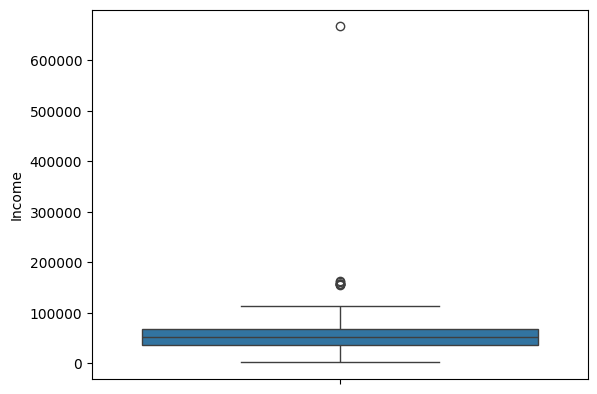

In [8]:
# Explore data to find outliers from each numeric col

sns.boxplot(df["Income"]) 

<Axes: ylabel='KidsHome'>

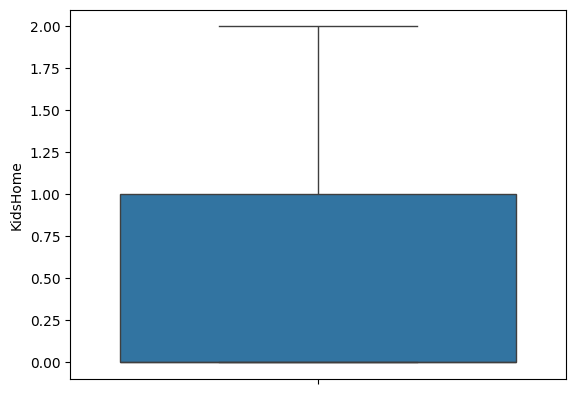

In [9]:
sns.boxplot(df["KidsHome"])

<Axes: ylabel='TeensHome'>

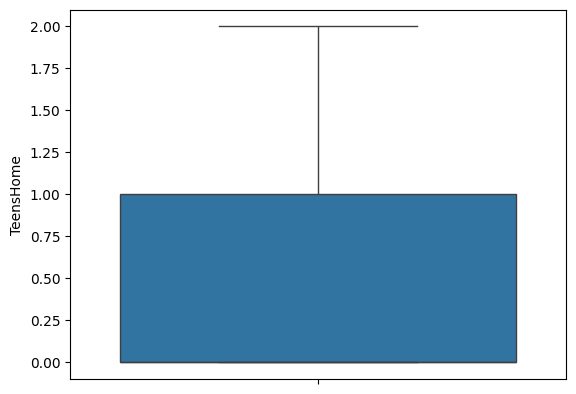

In [10]:
sns.boxplot(df["TeensHome"])

<Axes: ylabel='CustomerFrom'>

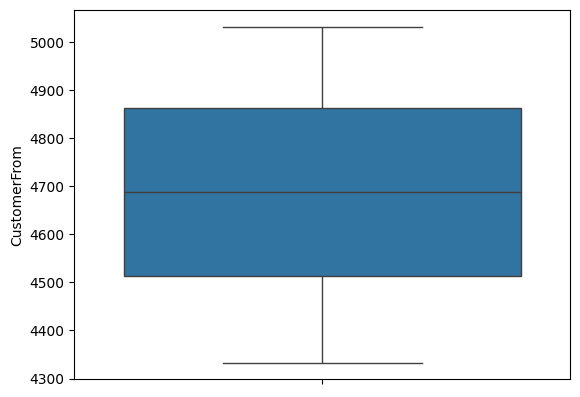

In [11]:
sns.boxplot(df["CustomerFrom"])

<Axes: ylabel='DaysLastPurchase'>

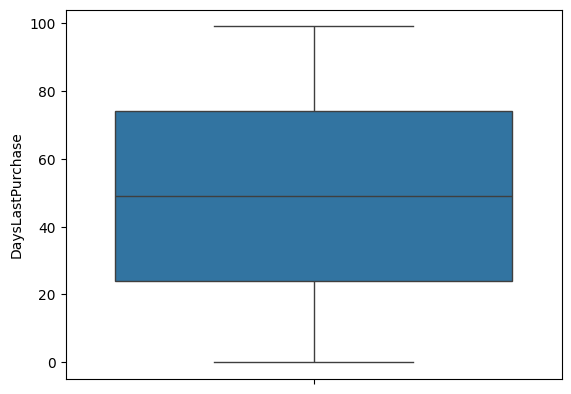

In [12]:
sns.boxplot(df["DaysLastPurchase"])

<Axes: ylabel='AmountWines'>

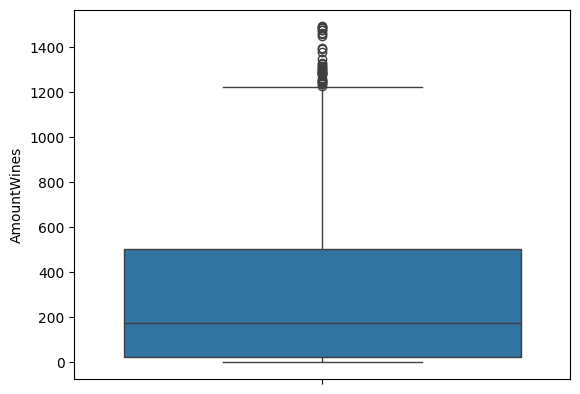

In [13]:
sns.boxplot(df["AmountWines"]) 

<Axes: ylabel='AmountFruits'>

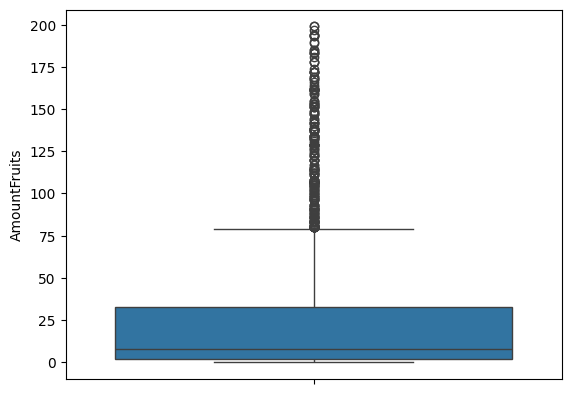

In [14]:
sns.boxplot(df["AmountFruits"]) 

<Axes: ylabel='AmountMeat'>

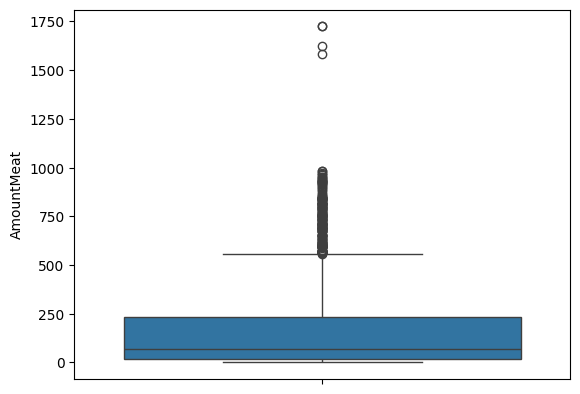

In [15]:
sns.boxplot(df["AmountMeat"]) 

<Axes: ylabel='AmountFish'>

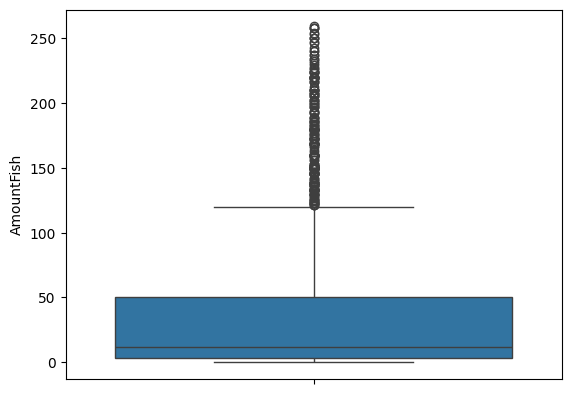

In [16]:
sns.boxplot(df["AmountFish"]) 

<Axes: ylabel='AmountSweets'>

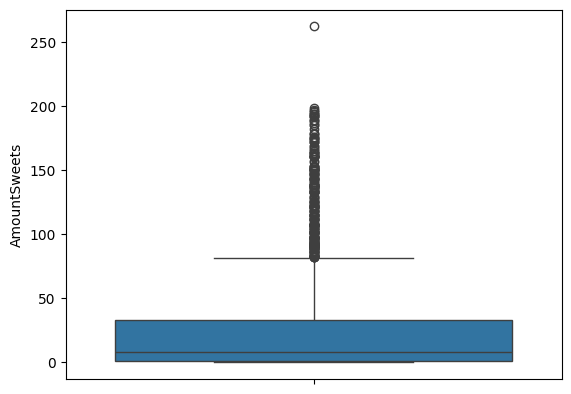

In [17]:
sns.boxplot(df["AmountSweets"]) 

<Axes: ylabel='AmountGoldProds'>

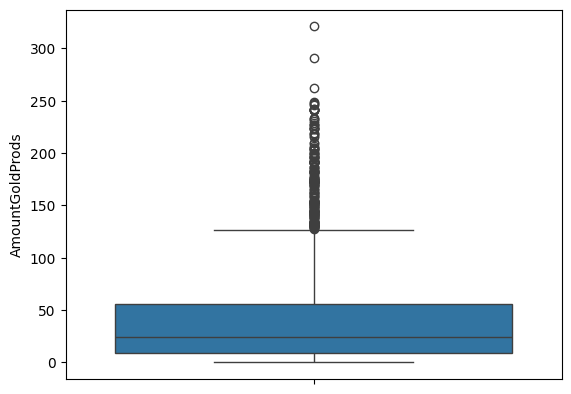

In [18]:
sns.boxplot(df["AmountGoldProds"]) 

<Axes: ylabel='NumDealsPurchases'>

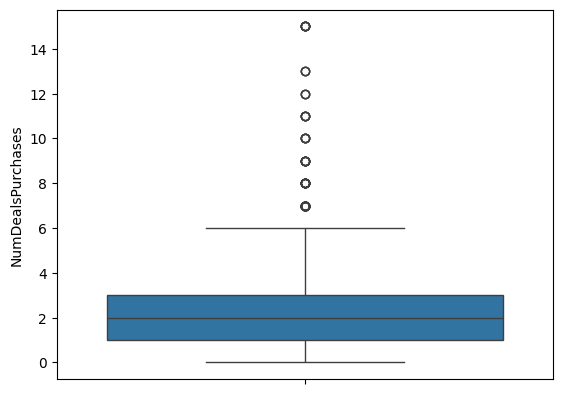

In [19]:
sns.boxplot(df["NumDealsPurchases"]) 

<Axes: ylabel='NumWebPurchases'>

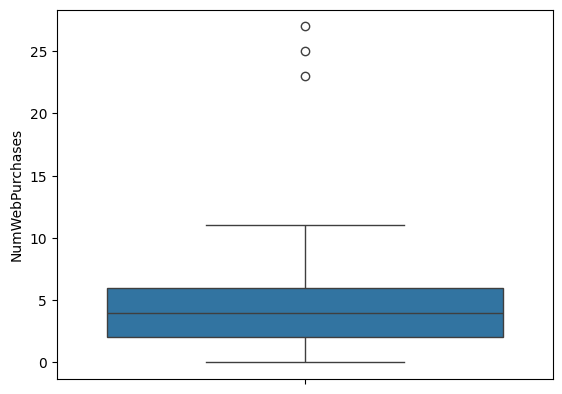

In [20]:
sns.boxplot(df["NumWebPurchases"]) 

<Axes: ylabel='NumCatalogPurchases'>

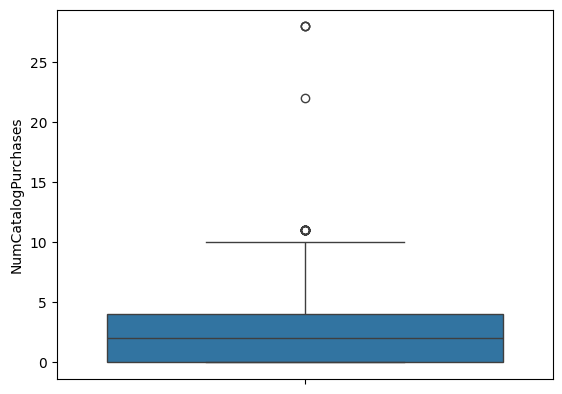

In [21]:
sns.boxplot(df["NumCatalogPurchases"]) 

<Axes: ylabel='NumStorePurchases'>

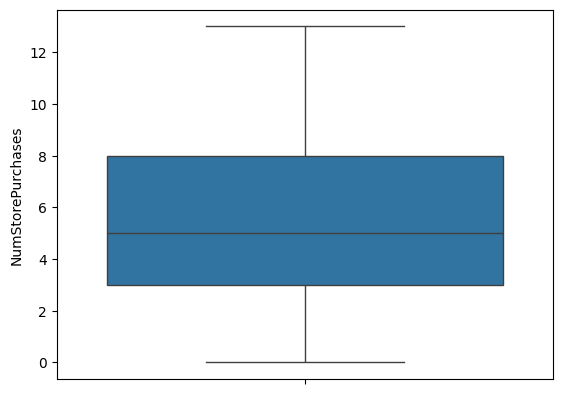

In [22]:
sns.boxplot(df["NumStorePurchases"])

<Axes: ylabel='NumWebVisitsMonth'>

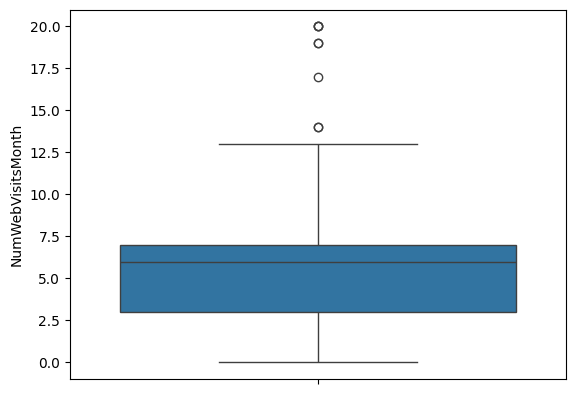

In [23]:
sns.boxplot(df["NumWebVisitsMonth"]) 

In [24]:
# Handle outliers by clipping 
cols_to_clip = ["Income", "AmountWines", "AmountFruits", "AmountMeat", "AmountFish", "AmountSweets", "AmountGoldProds", "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumWebVisitsMonth", "NumStorePurchases"]

stds = df[cols_to_clip].std(axis=0)
means = df[cols_to_clip].mean(axis=0)

df[cols_to_clip] = df[cols_to_clip].clip(
    lower=means - 3 * stds,
    upper=means + 3 * stds,
    axis=1
)

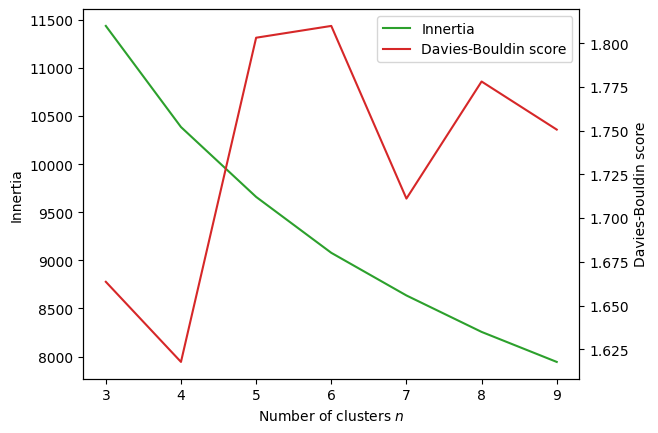

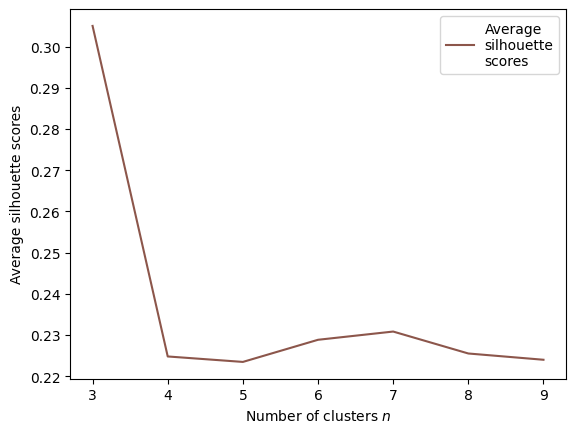

In [25]:
# Zadanie 2
# Starting with scaling selected features for first clustering try
scaler = StandardScaler()

# Arbitrarily chosen features for first clustering trial
X = df[[
    "Education", 
    "Income",  
    "AmountWines", 
    "AmountFruits", 
    "AmountMeat", 
    "AmountFish", 
    "AmountSweets", 
    "AmountGoldProds", 
    "NumWebVisitsMonth", 
    "NumStorePurchases"
]].values

X_scaled = scaler.fit_transform(X)

# Find number of cluster
inertias, dbs, silhouette_scores = [], [], []

for n in range(3, 10):
    k_means_test = KMeans(n_clusters=n, n_init=10)
    k_means_test.fit(X_scaled)
    inertias.append(k_means_test.inertia_)
    dbs.append(davies_bouldin_score(X_scaled, k_means_test.labels_))
    silhouette_scores.append(silhouette_score(X_scaled, k_means_test.labels_))

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
l1 = ax1.plot(range(3, 10), inertias, color='C2', label="Innertia")
l2 = ax2.plot(range(3, 10), dbs, color='C3', label='Davies-Bouldin score')
ax1.set_xlabel("Number of clusters $n$")
ax1.set_ylabel("Innertia")
ax2.set_ylabel("Davies-Bouldin score")
ax2.grid(False)
ax1.legend(handles=[l1[0], l2[0]], loc='upper right')
plt.show()

plt.plot(range(3, 10), silhouette_scores, color='C5', label='Average\nsilhouette\nscores')
plt.xlabel("Number of clusters $n$")
plt.ylabel('Average silhouette scores')
plt.legend(loc='upper right')
plt.show()



WCV = 10386.332674547746


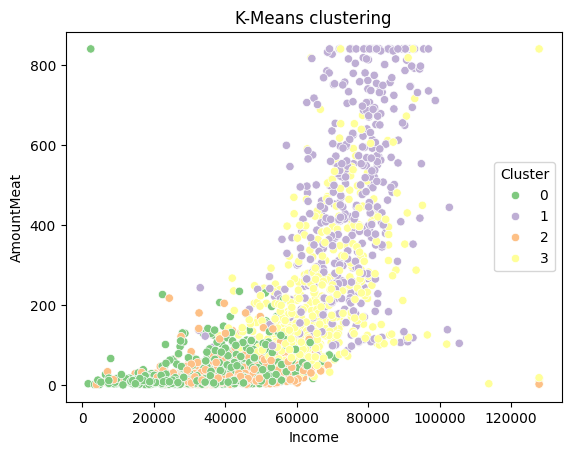

In [26]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print(f'WCV = {kmeans.inertia_}')

sns.scatterplot(df, x='Income', y='AmountMeat', hue='Cluster', palette='Accent')
plt.xlabel('Income')
plt.ylabel('AmountMeat')
plt.title('K-Means clustering')
plt.show()

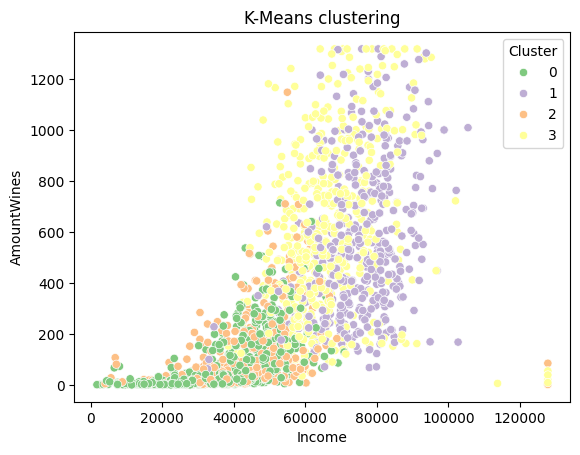

In [27]:
sns.scatterplot(df, x='Income', y='AmountWines', hue='Cluster', palette='Accent')
plt.xlabel('Income')
plt.ylabel('AmountWines')
plt.title('K-Means clustering')
plt.show()

Note to AmountWines features: We can clearly see that cluster 1 and 3 are highest cash spenders in wine sector. From around 60k annual income wine spending habit clearly rises.

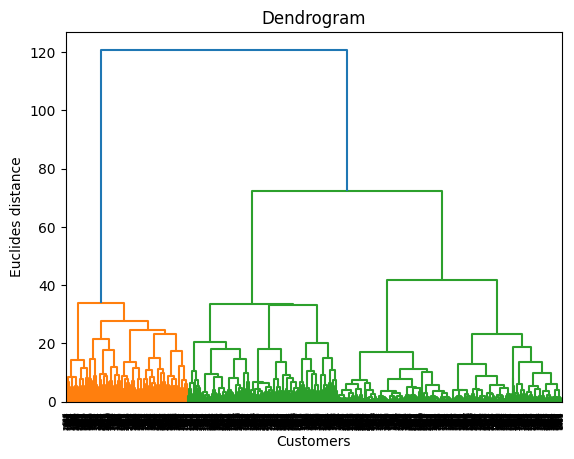

In [28]:
dendogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclides distance')
plt.show()

In [29]:
kl = KneeLocator(range(3, 10), inertias, curve="convex")
print(f'Knee locator based optimum cluster amount: {kl.elbow}')

Knee locator based optimum cluster amount: 9


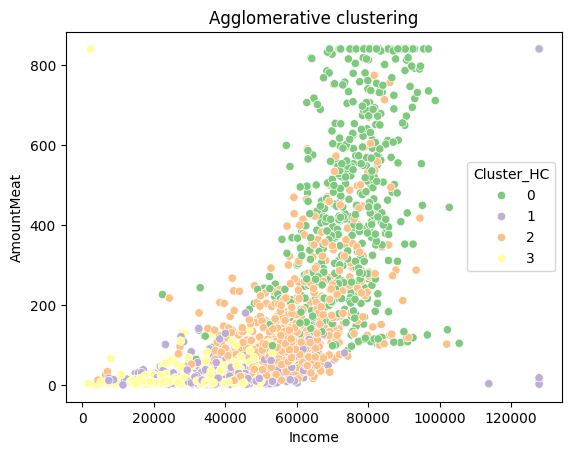

In [30]:

hc = AgglomerativeClustering(n_clusters=4)
df['Cluster_HC'] = hc.fit_predict(X_scaled)
sns.scatterplot(df, x='Income', y='AmountMeat', hue='Cluster_HC', palette='Accent')
plt.xlabel('Income')
plt.ylabel('AmountMeat')
plt.title('Agglomerative clustering')
plt.show()

/var/folders/8m/2bmbch8140x5z1y896yqv01r0000gn/T/ipykernel_49712/2140304776.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=kmeans.labels_, y=df['Income'], palette='Set2')


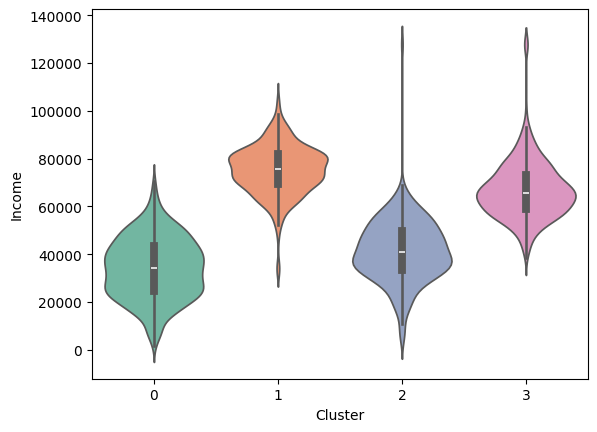

In [31]:
sns.violinplot(x=kmeans.labels_, y=df['Income'], palette='Set2')
plt.xlabel('Cluster')
plt.ylabel('Income')
plt.show()

/var/folders/8m/2bmbch8140x5z1y896yqv01r0000gn/T/ipykernel_49712/3253132209.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=kmeans.labels_, y=df['AmountMeat'], palette='Set2')


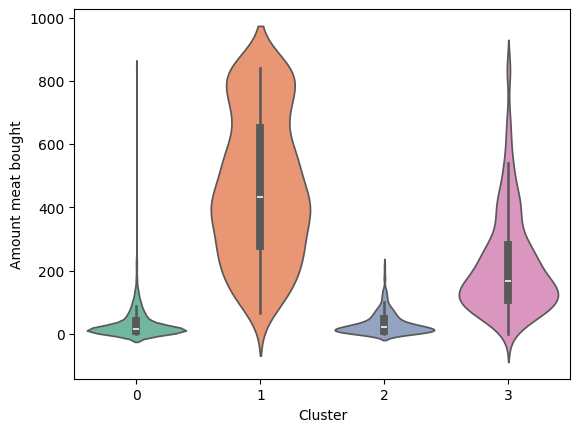

In [32]:
sns.violinplot(x=kmeans.labels_, y=df['AmountMeat'], palette='Set2')
plt.xlabel('Cluster')
plt.ylabel('Amount meat bought')
plt.show()

/var/folders/8m/2bmbch8140x5z1y896yqv01r0000gn/T/ipykernel_49712/1793350722.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=hc.labels_, y=df['AmountMeat'], palette='Set2')


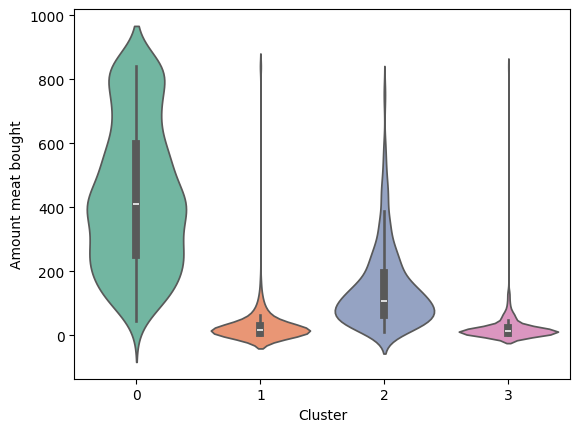

In [33]:
sns.violinplot(x=hc.labels_, y=df['AmountMeat'], palette='Set2')
plt.xlabel('Cluster')
plt.ylabel('Amount meat bought')
plt.show()

In [34]:
def get_sillhouette_diagram(X: np.ndarray, k_means: KMeans, n_clusters: int, scaler: StandardScaler, first_feature_idx: int,  sec_feature_idx: int) -> None:
    X_scaled = scaler.fit_transform(X=X)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])
    labels = k_means.fit_predict(X_scaled)
    savg = silhouette_score(X_scaled, labels)
    ssv = silhouette_samples(X_scaled, labels)
    y_lower = 10

    for i in range(n_clusters):
        icsv = ssv[labels == i]
        icsv.sort()
        sci = icsv.shape[0]
        y_upper = y_lower + sci
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, icsv, facecolor=color,
        edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * sci, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=savg, color="red", linestyle="--")
    ax1.set_title("Silhouette diagram")
    ax1.set_xlabel("Silhouette score")
    ax1.set_ylabel("Cluster label")
    ax1.set_yticks([])
    ax1.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    colors = cm.nipy_spectral(labels.astype(float) / n_clusters)
    ax2.scatter(X[:, first_feature_idx], X[:, sec_feature_idx], marker=".", s=30, lw=0, alpha=0.7, c=colors,edgecolor="k")
    fig.tight_layout()

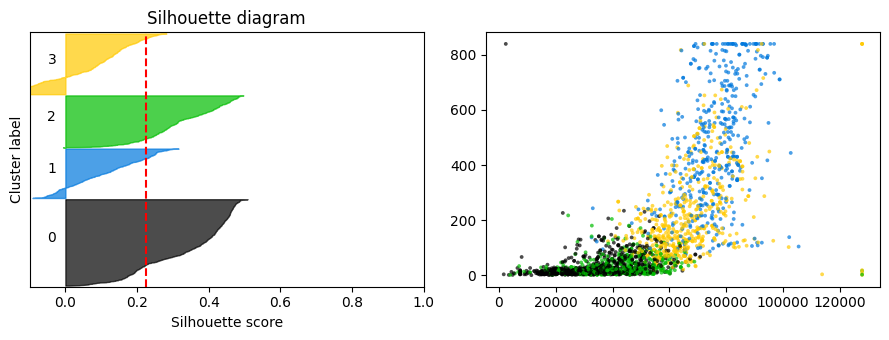

In [38]:
get_sillhouette_diagram(
    X=X,
    scaler=scaler,
    k_means=kmeans,
    n_clusters=4,
    first_feature_idx=1,
    sec_feature_idx=4
)

#### Summary of first try K-Means and AgglomerativeClustering

The first attempt seems to be noisy. I decided to not include every feature from dataframe in X variable, as K-Means is sensitive for dataseta dimensionality.

The optimal cluster amount appears to be 4 according to Davies-Bouldin and Silhouette scores. The Dendrogram chart displayed a distinction into two separate clusters, but from a business perspective, dividing customers into only two groups is not informative at all. When comparing relations like Income vs Amount of Meat bought, it is very easy to distinguish two clusters. This can be done very intuitively by drawing a line in the middle of the plot (figuratively speaking). We can then simply assume we have two groups: low earners and high earners, but this information alone is very shallow and carries little business value for marketing teams.
Four clusters seem to be optimal according to the hyperparameter search. We distinguish four groups:

1. Low income people, who buy fewer products due to the necessity of saving money and having less disposable income in general.

2 & 3. Two mid-level income groups, where spending habits can depend on individual behavior. One group represents the lower bound mid-tier, and the second naturally has slightly higher income and higher spending habits.

4. High income people, where we naturally observe the highest amounts of products purchased and the highest overall spending.

Using 4 clusters and looking at the silhouette diagram and violin plots, we can make initial assumptions that clusters labeled 0 and 2 can be somewhat targeted with business marketing strategies. What is good, is the fact that both algorithms - K-Means and Agglomerative clustering aggregates customers into similar looking clusters - naturally labeled differently but looking at violin plot of AmountMeat feature for hc and kmeans gives us similar plots.

The groupings are wider, and beyond the red average score line we observe a wide spread — meaning the points appear to be correctly assigned to their clusters, which can guide targeted commercial decisions.
The blue cluster has some negative scores, which suggests the model had difficulty correctly assigning some customers, and does not see clear boundaries for that cluster. This indicates we should consider better grouping methodologies, as the first attempt gives us some hints about customer segments but clearly shows significant room for model improvement.

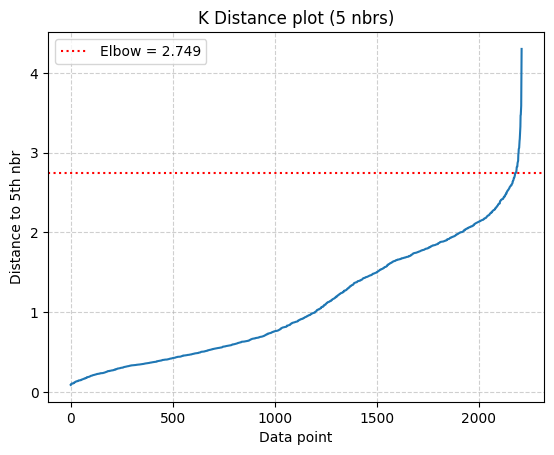

Suggested eps: 2.7486


In [52]:
# Zadanie 3
nn = NearestNeighbors(n_neighbors=5)  # 5 neighbors (index 0 = self, so 4 true neighbors + self)
nbrs = nn.fit(X_scaled)

distances, indices = nn.kneighbors(X_scaled)
distances = distances[:, 4]
distances = np.sort(distances)

kl = KneeLocator(
    range(len(distances)),
    distances,
    curve='convex',
    direction='increasing'
)

plt.figure()
plt.plot(distances)
plt.axhline(distances[kl.elbow], color='r', linestyle=':', label=f'Elbow = {distances[kl.elbow]:.3f}')
plt.title("K Distance plot (5 nbrs)")
plt.xlabel("Data point")
plt.ylabel("Distance to 5th nbr")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

print(f"Suggested eps: {distances[kl.elbow]:.4f}")

In [82]:
def find_db_scan_hp(X_scaled):
    min_samples = range(3, 8)
    eps = np.arange(1.6, 2.2, 0.01)
    silhsc = {}
    for ms in min_samples:
        silhsc[ms] = []
        for ep in eps:
            labels = DBSCAN(min_samples=ms, eps = ep).fit_predict(X_scaled)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            if n_clusters == 2:
                silhsc[ms].append((n_clusters, ep, silhouette_score(X_scaled, labels)))
        silhsc[ms] = sorted(silhsc[ms], key=lambda x:x[-1])[-1]
    print(pd.DataFrame(silhsc).T.reset_index().rename(columns={'index': 'NumPts', 0: 'Liczba klastrów', 1: 'epsilon',2: 'Współczynnik sylwetki'}))

In [83]:
find_db_scan_hp(X_scaled=X_scaled)

   NumPts  Liczba klastrów  epsilon  Współczynnik sylwetki
0       3              2.0     2.14               0.244756
1       4              2.0     1.95               0.252943
2       5              2.0     2.07               0.265871
3       6              2.0     2.02               0.289722
4       7              2.0     1.63               0.298844


In [89]:
labels = DBSCAN(min_samples=7, eps=1.63).fit_predict(X_scaled)

ss = silhouette_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print(ss, db, ch)
print(f"Silhouette score: {ss}")
print(f"davies bouldin scores: {db}")
print(f"calinski hrabasz score: {ch}")


print("Number of cluster: ", n_clusters)
noise_points = np.sum(labels == -1)
print(f"Amount of points intepreted as noise: {noise_points}")

unique_labels, counts = np.unique(labels[labels != -1], return_counts=True)
print(dict(zip(unique_labels, counts)))

0.298844299422827 1.5274413998533232 467.4374420093284
Silhouette score: 0.298844299422827
davies bouldin scores: 1.5274413998533232
calinski hrabasz score: 467.4374420093284
Number of cluster:  2
Amount of points intepreted as noise: 556
{np.int64(0): np.int64(1646), np.int64(1): np.int64(10)}


SUMMARY: 